<h1>War Damage Detection Pipeline</h1>

A modular, config driven pipeline for detecting building damage from satellite imagery,
built for the group project "Quantifying War Damage from Satellite Imagery".

Everything an experiment needs is controlled from the CONFIG dictionary in Section 1.
Changing features, model architecture, cities, patch size or augmentation should never
require edits anywhere else in the notebook. Each section below is self contained and
replaceable, so the group can swap in better components without breaking the rest.

What the pipeline expects on disk:
<ul>
<li>The PWTT one_month benchmark extracted next to this notebook, giving files named
<code>one_month/{City}_{YYYYMMDD}_1_footprints.csv</code> or
<code>..._1_grid.csv</code>. These carry the geometry, the UNOSAT derived damage label
and the PWTT statistics.</li>
<li>Nothing else. Sentinel 1 and Sentinel 2 rasters are exported from Google Earth
Engine by Section 2b on first use and cached in <code>rasters/</code>, so a fresh
checkout only needs the PWTT labels and a GEE account.</li>
</ul>

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
!pip install geedim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.0 MB/s eta 0:00:00


<h2>1. Setup and configuration</h2>

The single source of truth for an experiment. The config is validated, then saved to the
experiment output folder so every run is reproducible. Outputs are organized as
<code>experiments/{experiment_name}/</code> with subfolders for models, metrics,
figures and predictions.

In [17]:
import os
import json
import copy
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from shapely.geometry import shape
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (precision_recall_fscore_support, average_precision_score,
                             roc_auc_score, precision_recall_curve)

CONFIG = {
    "experiment_name": "exp001_small_cnn_sar",
    "seed": 0,

    # "classification" predicts one label per building patch
    # "segmentation" is a placeholder for per pixel damage maps, see Section 7
    "task": "classification",

    # PWTT ships two geometries per city and date. footprints anchors patches on
    # buildings, grid anchors them on regular cells. Both files carry the same
    # columns so everything downstream is identical.
    "label_geometry": "footprints",

    # Feature switches. The pipeline builds the widest stack available per city
    # and these select which channels and tables the model actually sees.
    "features": {
        "sentinel1": True,
        "sentinel2": False,
        "pwtt_tabular": False,
        "pre_event": True,
        "post_event": True,
    },

    # Imagery export settings. These define what the rasters contain, and they
    # are baked into the raster filename so changing them forces a new export
    # instead of silently reusing the old one.
    "imagery": {
        "gee_project": "test-cnn-war-damage",
        "pre_months": 12,              # pre war baseline length
        "post_months": 1,              # post window length, matches one_month
        "post_direction": "forward",   # forward is PWTT convention, backward avoids lookahead
        "scale": 10,                   # meters per pixel
        "aoi_buffer_deg": 0.005,       # padding so edge buildings still get a full patch
        "s2_max_cloud": 60,
        "raster_dir": "rasters",
        "min_aoi_coverage": 0.90,      # warn if the chosen orbit misses part of the city
    },

    # One of the keys in MODEL_REGISTRY (Section 7): small_cnn, two_branch,
    # siamese, unet. New architectures register themselves with @register_model.
    "model": "small_cnn",

    "patch_size": 32,
    "batch_size": 128,
    "learning_rate": 1e-3,
    "max_epochs": 60,
    "early_stopping_patience": 12,

    # Split entries are either "City" for the whole city or "City:lo-hi" for a
    # latitude band, where lo and hi are quantiles of building latitude. Bands let
    # us split a single city into spatially disjoint train, val and test regions.
    "split": {
        "train": ["Gaza:0.55-1.00"],
        "val":   ["Gaza:0.33-0.55"],
        "test":  ["Gaza:0.00-0.33", "Raqqa", "Aleppo", "Irpin", "Bucha"],
    },

    "augmentation": {
        # random flips and 90 degree rotations during training
        "geometric": True,
        # propagate labels across assessment dates, destroyed stays destroyed
        # and before the first damaged label a building counts as intact
        "label_temporal": False,
        # blend each building score with its neighbours at inference time,
        # damage is spatially clustered so neighbours carry information
        "spatial_smoothing": {"enabled": False, "k": 8, "weight": 0.3},
    },

    # cap on rows per city, None means use every row in the label file
    "n_sample": 4000,

    "output_root": "experiments",
}


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)


def validate_config(cfg):
    """Fail early with a readable message instead of a confusing crash later."""
    f = cfg["features"]
    if not (f["sentinel1"] or f["sentinel2"]):
        raise ValueError("enable at least one imaging feature, sentinel1 or sentinel2")
    if not (f["pre_event"] or f["post_event"]):
        raise ValueError("enable at least one of pre_event or post_event")
    if cfg["model"] == "two_branch" and not (f["sentinel1"] and f["sentinel2"]):
        raise ValueError("two_branch needs both sentinel1 and sentinel2 enabled")
    if cfg["model"] == "siamese" and not (f["pre_event"] and f["post_event"]):
        raise ValueError("siamese compares pre and post, enable both")
    if cfg["task"] == "segmentation" and cfg["model"] != "unet":
        raise ValueError("segmentation currently expects the unet model")
    if cfg["label_geometry"] not in ("footprints", "grid"):
        raise ValueError("label_geometry must be footprints or grid")
    if cfg["imagery"]["post_direction"] not in ("forward", "backward"):
        raise ValueError("post_direction must be forward or backward")


def make_output_dirs(cfg):
    root = os.path.join(cfg["output_root"], cfg["experiment_name"])
    dirs = {name: os.path.join(root, name)
            for name in ["models", "metrics", "figures", "predictions"]}
    for d in dirs.values():
        os.makedirs(d, exist_ok=True)
    with open(os.path.join(root, "config.json"), "w") as fh:
        json.dump(cfg, fh, indent=2)
    return root, dirs


validate_config(CONFIG)
set_seed(CONFIG["seed"])
device = "cuda" if torch.cuda.is_available() else "cpu"
EXP_ROOT, OUT = make_output_dirs(CONFIG)
print(f"experiment folder: {EXP_ROOT}")
print(f"device: {device}")

experiment folder: experiments/exp001_small_cnn_sar
device: cuda


<h2>2. Data registry and label loading</h2>

One registry entry per city holding what is needed to find its labels and export its
imagery. Adding a city means adding a dictionary here or calling <code>add_city</code>,
and nothing else in the notebook changes.

Registry entries deliberately do not contain raster paths. Paths are derived from the
city, the assessment date and the imagery settings, so two experiments with different
window lengths cannot accidentally share a raster.

In [18]:
# label_dates lists the UNOSAT assessment dates available for the city, oldest
# first. Several dates per city is what powers temporal label augmentation.
# war_start is the conflict start used for the pre war baseline window.
CITY_REGISTRY = {
    "Gaza":   {"label_dates": ["20240503"], "war_start": "2023-10-07"},
    "Raqqa":  {"label_dates": ["20171021"], "war_start": "2017-06-06"},
    "Aleppo": {"label_dates": ["20160918"], "war_start": "2016-07-01"},
    "Irpin":  {"label_dates": ["20220331"], "war_start": "2022-02-24"},
    "Bucha":  {"label_dates": ["20220331"], "war_start": "2022-02-24"},
}

DATA_DIR = "/content/drive/MyDrive/War-Damage-Detection/one_month"

# PWTT columns we treat as tabular features. damage_pts is banned on purpose,
# it counts the UNOSAT points that created the label, so using it is leakage.
TAB_FEATURES = ["k50", "k100", "k150", "max_change", "area"]

# Sentinel 1 IW GRD only becomes routinely available in late 2014. Aleppo in
# particular sits close to this limit, so the exporter warns rather than
# silently producing an empty pre war composite.
S1_EARLIEST = "2014-10-01"


def add_city(name, label_dates, war_start):
    """Register a new city at runtime. Imagery is exported on first use."""
    CITY_REGISTRY[name] = {"label_dates": list(label_dates), "war_start": war_start}


def label_path(city, date, cfg=None):
    """PWTT label file for one city and assessment date."""
    kind = (cfg or CONFIG)["label_geometry"]
    return os.path.join(DATA_DIR, f"{city}_{date}_1_{kind}.csv")


def load_labels(city, date, cfg=None):
    """Read one PWTT CSV into a GeoDataFrame with centroid points."""
    path = label_path(city, date, cfg)
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{path} not found. Check that the PWTT one_month folder is extracted "
            f"next to this notebook and that {city} has an assessment on {date}.")
    df = pd.read_csv(path, low_memory=False)
    geoms = [shape(json.loads(g)) for g in df[".geo"]]
    gdf = gpd.GeoDataFrame(df.drop(columns=[".geo"]), geometry=geoms, crs="EPSG:4326")
    # centroids computed in a projected system, then converted back to lon lat
    gdf["centroid"] = gdf.geometry.to_crs(3857).centroid.to_crs(4326)
    return gdf


def city_bbox(city, date, cfg=None):
    """AOI for the export, taken from the labelled geometries plus a buffer."""
    cfg = cfg or CONFIG
    gdf = load_labels(city, date, cfg)
    minx, miny, maxx, maxy = gdf.total_bounds
    b = cfg["imagery"]["aoi_buffer_deg"]
    return [minx - b, miny - b, maxx + b, maxy + b]


def raster_path(city, date, sensor, cfg=None):
    """Filename encodes the export settings so different windows never collide."""
    im = (cfg or CONFIG)["imagery"]
    os.makedirs(im["raster_dir"], exist_ok=True)
    tag = f"pre{im['pre_months']}m_{im['post_direction']}{im['post_months']}m"
    return os.path.join(im["raster_dir"], f"{city.lower()}_{date}_{sensor}_{tag}.tif")

<h2>2b. Imagery export from Google Earth Engine</h2>

Builds the rasters the rest of the pipeline consumes. Runs once per city, date and
imagery setting, then everything is read from disk.

<b>Sentinel 1</b> gives a 4 band stack, pre_VV, pre_VH, post_VV, post_VH, in dB. Pre and
post come from the same relative orbit, because mixing orbits injects incidence angle
differences that look like change but are not damage. Orbits are chosen by measured AOI
coverage rather than image count, since a scene that merely clips one corner of a city
counts the same as one that covers it fully.

<b>Sentinel 2</b> gives an 8 band stack, pre and post B2, B3, B4 and B8, all native
10 m. Surface reflectance only exists from about March 2017, so older cities fall back
to top of atmosphere and the exporter says so.

Damage is cumulative, so a composite encodes damage up to the window <i>end</i>. The
<code>post_direction</code> setting decides the tradeoff. forward matches PWTT and gives
undiluted positives at the cost of one month of lookahead past the assessment date,
backward avoids the lookahead but dilutes buildings destroyed inside the window.

In [19]:
def _init_ee(cfg=None):
    import ee
    project = (cfg or CONFIG)["imagery"]["gee_project"]
    try:
        ee.Initialize(project=project)
    except Exception:
        ee.Authenticate()
        ee.Initialize(project=project)
    return ee


def _windows(war_start, label_date, cfg):
    """Return the pre and post date windows as Earth Engine dates."""
    import ee
    im = cfg["imagery"]
    war, label = ee.Date(war_start), ee.Date(label_date)
    pre = (war.advance(-im["pre_months"], "month"), war)
    if im["post_direction"] == "forward":
        post = (label, label.advance(im["post_months"], "month"))
    else:
        post = (label.advance(-im["post_months"], "month"), label)
    return pre, post


def _iso(date):
    """20240503 becomes 2024-05-03."""
    return f"{date[:4]}-{date[4:6]}-{date[6:]}"


def export_s1(city, date, bbox, cfg=None):
    """Export a 4 band SAR stack, pre_VV, pre_VH, post_VV, post_VH, in dB."""
    cfg = cfg or CONFIG
    out = raster_path(city, date, "s1", cfg)
    if os.path.exists(out):
        print(f"  {out} exists, skipping export")
        return out

    ee = _init_ee(cfg)
    import geemap
    im = cfg["imagery"]
    aoi = ee.Geometry.Rectangle(bbox)
    (pre_a, pre_b), (post_a, post_b) = _windows(
        CITY_REGISTRY[city]["war_start"], _iso(date), cfg)

    if pre_a.format("YYYY-MM-dd").getInfo() < S1_EARLIEST:
        print(f"  WARNING: pre window starts before {S1_EARLIEST}, Sentinel 1 has "
              f"no data there. Move war_start later or shorten pre_months.")

    # Border noise and out of swath pixels are minus infinity in dB, the log of
    # zero. Mask them before compositing or a single pixel poisons the channel.
    def mask_edges(img):
        valid = img.select("VV").gt(-35).And(img.select("VH").gt(-35))
        return img.updateMask(valid)

    s1 = (ee.ImageCollection("COPERNICUS/S1_GRD").filterBounds(aoi)
          .filter(ee.Filter.eq("instrumentMode", "IW"))
          .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
          .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
          .select(["VV", "VH"]).map(mask_edges))

    def orbit_counts(a, b):
        # aggregate_histogram returns string keys and the orbit number is stored
        # as a double, so keys look like 160.0 and plain int() would raise
        h = (s1.filterDate(a, b)
               .aggregate_histogram("relativeOrbitNumber_start").getInfo())
        return {int(float(k)): int(v) for k, v in h.items()}

    pre_c, post_c = orbit_counts(pre_a, pre_b), orbit_counts(post_a, post_b)
    shared = set(pre_c) & set(post_c)
    if not shared:
        raise RuntimeError(f"{city}: no orbit covers both windows. "
                           f"pre={pre_c} post={post_c}")

    # Image count is not coverage. filterBounds keeps any scene that merely
    # touches the AOI, so an orbit can look well sampled while covering almost
    # none of the city. Measure the AOI fraction that actually has observations.
    def coverage(a, b, orbit):
        c = s1.filterDate(a, b).filter(
            ee.Filter.eq("relativeOrbitNumber_start", orbit))
        m = c.select("VV").count().gt(0).unmask(0)
        return m.reduceRegion(ee.Reducer.mean(), aoi, 200, maxPixels=1e9).get("VV")

    cov = ee.Dictionary({
        f"{o}_{w}": coverage(a, b, o)
        for o in shared
        for w, (a, b) in [("pre", (pre_a, pre_b)), ("post", (post_a, post_b))]
    }).getInfo()

    scored = {o: min(cov[f"{o}_pre"] or 0, cov[f"{o}_post"] or 0) for o in shared}
    best = max(scored, key=lambda o: (scored[o], post_c[o]))
    for o in sorted(shared):
        print(f"  orbit {o}: {pre_c[o]:3d} pre / {post_c[o]:3d} images, coverage "
              f"{cov[f'{o}_pre'] or 0:.2f} pre / {cov[f'{o}_post'] or 0:.2f} post")
    print(f"  using orbit {best}, min coverage {scored[best]:.2f}")
    if scored[best] < im["min_aoi_coverage"]:
        print(f"  WARNING: best orbit covers only {scored[best] * 100:.0f} percent "
              f"of the AOI, most of the export will be nodata. Shrink the AOI, "
              f"widen the windows, or drop this city.")
    if post_c[best] < 3:
        print(f"  WARNING: only {post_c[best]} post images. A median over so few "
              f"acquisitions barely suppresses speckle, consider post_months 2.")

    s1 = s1.filter(ee.Filter.eq("relativeOrbitNumber_start", best))
    pre = s1.filterDate(pre_a, pre_b).median().rename(["pre_VV", "pre_VH"])
    post = s1.filterDate(post_a, post_b).median().rename(["post_VV", "post_VH"])
    stack = pre.addBands(post).clip(aoi).toFloat()
    geemap.download_ee_image(stack, out, region=aoi, scale=im["scale"],
                             crs="EPSG:4326")
    print(f"  exported {out}")
    return out


def export_s2(city, date, bbox, cfg=None):
    """Export an 8 band optical stack, pre and post B2 B3 B4 B8, all native 10 m."""
    cfg = cfg or CONFIG
    out = raster_path(city, date, "s2", cfg)
    if os.path.exists(out):
        print(f"  {out} exists, skipping export")
        return out

    ee = _init_ee(cfg)
    import geemap
    im = cfg["imagery"]
    aoi = ee.Geometry.Rectangle(bbox)
    bands = ["B2", "B3", "B4", "B8"]
    (pre_a, pre_b), (post_a, post_b) = _windows(
        CITY_REGISTRY[city]["war_start"], _iso(date), cfg)

    def mask_scl(img):
        # level 2A scene classification, 3 shadow, 8 and 9 cloud, 10 cirrus
        scl = img.select("SCL")
        bad = scl.eq(3).Or(scl.eq(8)).Or(scl.eq(9)).Or(scl.eq(10))
        return img.updateMask(bad.Not())

    def mask_qa60(img):
        # level 1C cloud bits, opaque cloud is bit 10 and cirrus is bit 11
        qa = img.select("QA60")
        clear = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
        return img.updateMask(clear)

    def composite(a, b):
        # Surface reflectance only exists from about March 2017, so older cities
        # such as Aleppo have to fall back to top of atmosphere.
        for cid, fn, level in [("COPERNICUS/S2_SR_HARMONIZED", mask_scl, "SR"),
                               ("COPERNICUS/S2_HARMONIZED", mask_qa60, "TOA")]:
            col = (ee.ImageCollection(cid).filterBounds(aoi).filterDate(a, b)
                   .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE",
                                        im["s2_max_cloud"])))
            n = col.size().getInfo()
            if n > 0:
                return col.map(fn).select(bands).median(), n, level
        return None, 0, "none"

    pre, n_pre, lvl_pre = composite(pre_a, pre_b)
    post, n_post, lvl_post = composite(post_a, post_b)
    print(f"  Sentinel 2 scenes: {n_pre} pre ({lvl_pre}) / {n_post} post ({lvl_post})")
    if n_pre == 0 or n_post == 0:
        raise RuntimeError(f"{city}: no usable Sentinel 2 scenes in one of the "
                           f"windows. Raise s2_max_cloud or widen the windows.")
    if lvl_pre != lvl_post:
        print("  WARNING: pre and post use different processing levels. TOA and SR "
              "are not radiometrically comparable, so their difference is "
              "contaminated by atmosphere. Force both to TOA if optical matters.")

    stack = (pre.rename([f"pre_{b}" for b in bands])
                .addBands(post.rename([f"post_{b}" for b in bands]))
                .clip(aoi).toFloat())
    geemap.download_ee_image(stack, out, region=aoi, scale=im["scale"],
                             crs="EPSG:4326")
    print(f"  exported {out}")
    return out


def ensure_rasters(city, date, cfg=None):
    """Return raster paths for one city and date, exporting whatever is missing.

    Sentinel 2 is only exported when the config asks for it, because every export
    costs Earth Engine compute quota and most experiments are SAR only.
    """
    cfg = cfg or CONFIG
    wanted = []
    if cfg["features"]["sentinel1"]:
        wanted.append("s1")
    if cfg["features"]["sentinel2"]:
        wanted.append("s2")

    paths = {"s1": None, "s2": None}
    missing = [s for s in wanted
               if not os.path.exists(raster_path(city, date, s, cfg))]
    bbox = city_bbox(city, date, cfg) if missing else None
    if missing:
        print(f"{city} {date}: exporting {missing}, AOI {[round(v, 4) for v in bbox]}")

    exporters = {"s1": export_s1, "s2": export_s2}
    for sensor in wanted:
        if sensor in missing:
            paths[sensor] = exporters[sensor](city, date, bbox, cfg)
        else:
            paths[sensor] = raster_path(city, date, sensor, cfg)
    return paths

<h2>3. Preprocessing</h2>

Turns rasters plus labels into per building patch arrays. Each city records which
channels it actually has, so a city exported without optical simply reports four
channels and feature selection in Section 4 resolves channels by name rather than by
position. Extraction is cached per session because it is the slow step.

Sentinel 1 pixels outside the swath are minus infinity in dB, not NaN, which is why the
validity check uses <code>np.isfinite</code>. That distinction cost us a full day on
Mariupol, where 96 percent of patches were silently poisoned.

In [20]:
# Names of every channel the pipeline knows about, in export order per sensor.
S1_CHANNELS = ["s1_pre_VV", "s1_pre_VH", "s1_post_VV", "s1_post_VH"]
S2_CHANNELS = ["s2_pre_B2", "s2_pre_B3", "s2_pre_B4", "s2_pre_B8",
               "s2_post_B2", "s2_post_B3", "s2_post_B4", "s2_post_B8"]
FULL_CHANNELS = S1_CHANNELS + S2_CHANNELS


def read_raster(path):
    with rasterio.open(path) as src:
        return src.read().astype(np.float32), ~src.transform, src.height, src.width


def extract_city(city, date, cfg=None):
    """Return one dictionary with everything downstream sections need.

    Rows whose window leaves any raster, or which touch a non finite pixel, are
    dropped so every model in an experiment sees the same clean set.
    """
    cfg = cfg or CONFIG
    patch = cfg["patch_size"]
    gdf = load_labels(city, date, cfg)
    if cfg["n_sample"] is not None and len(gdf) > cfg["n_sample"]:
        gdf = gdf.sample(cfg["n_sample"], random_state=cfg["seed"])
    gdf = gdf.copy()

    paths = ensure_rasters(city, date, cfg)
    rasters, names = [], []
    if paths["s1"]:
        rasters.append(read_raster(paths["s1"]))
        names += S1_CHANNELS
    if paths["s2"]:
        rasters.append(read_raster(paths["s2"]))
        names += S2_CHANNELS

    xs = gdf["centroid"].apply(lambda p: p.x).values
    ys = gdf["centroid"].apply(lambda p: p.y).values
    half = patch // 2

    corner_list = []
    for arr, inv, H, W in rasters:
        cols, rows = inv * (xs, ys)
        r0 = np.round(rows).astype(int) - half
        c0 = np.round(cols).astype(int) - half
        ok = (r0 >= 0) & (c0 >= 0) & (r0 + patch <= H) & (c0 + patch <= W)
        corner_list.append((r0, c0, ok))
    ok_all = np.logical_and.reduce([c[2] for c in corner_list])

    X, keep = [], []
    idx = gdf.index.values
    for j in np.where(ok_all)[0]:
        parts, good = [], True
        for (arr, inv, H, W), (r0, c0, ok) in zip(rasters, corner_list):
            p = arr[:, r0[j]:r0[j] + patch, c0[j]:c0[j] + patch]
            if not np.isfinite(p).all():
                good = False
                break
            parts.append(p)
        if good:
            X.append(np.concatenate(parts, axis=0))
            keep.append(idx[j])

    if not X:
        raise RuntimeError(f"{city} {date}: no usable patches. The raster is "
                           f"probably mostly nodata, check the orbit coverage "
                           f"warning printed by Section 2b.")

    keep = np.array(keep)
    sub = gdf.loc[keep]
    tab = sub[TAB_FEATURES].to_numpy(np.float32)
    if not np.isfinite(tab).all():
        med = np.nanmedian(np.where(np.isfinite(tab), tab, np.nan), axis=0)
        tab = np.where(np.isfinite(tab), tab, med)

    out = {
        "city": city,
        "date": date,
        "X": np.stack(X),
        "tab": tab,
        "y": sub["class"].to_numpy(int),
        "gdf": sub,
        "lat": sub["centroid"].apply(lambda p: p.y).values,
        "channel_names": names,
    }
    print(f"{city} {date}: kept {len(keep)} of {len(gdf)}, "
          f"{out['y'].mean() * 100:.2f} percent damaged, {len(names)} channels")
    return out


# cache so each city is extracted once per session
_city_cache = {}


def get_city(city, date=None, cfg=None):
    cfg = cfg or CONFIG
    date = date or CITY_REGISTRY[city]["label_dates"][-1]
    key = (city, date, cfg["patch_size"], cfg["label_geometry"],
           cfg["features"]["sentinel1"], cfg["features"]["sentinel2"])
    if key not in _city_cache:
        _city_cache[key] = extract_city(city, date, cfg)
    return _city_cache[key]

<h2>4. Feature construction</h2>

Maps the feature switches in CONFIG to concrete channels. Selection happens by channel
<i>name</i>, not by position, so a city exported with only SAR and a city exported with
SAR plus optical both work without special cases. Models never index raw channels, they
ask this section what is active.

Adding a new data source means appending its channel names here, teaching
<code>extract_city</code> to read the raster, and adding a switch in CONFIG.

In [21]:
def wanted_channel_names(cfg=None):
    """Channel names the config asks for, in canonical order."""
    cfg = cfg or CONFIG
    f = cfg["features"]
    names = []
    for name in FULL_CHANNELS:
        if name.startswith("s1") and not f["sentinel1"]:
            continue
        if name.startswith("s2") and not f["sentinel2"]:
            continue
        if "_pre_" in name and not f["pre_event"]:
            continue
        if "_post_" in name and not f["post_event"]:
            continue
        names.append(name)
    return names


CHANNEL_NAMES = wanted_channel_names(CONFIG)
N_CHANNELS = len(CHANNEL_NAMES)
N_TAB = len(TAB_FEATURES) if CONFIG["features"]["pwtt_tabular"] else 0
print(f"active channels ({N_CHANNELS}): {CHANNEL_NAMES}")
print(f"tabular features ({N_TAB}): {TAB_FEATURES if N_TAB else 'none'}")


def select_channels(city_dict, cfg=None):
    """Slice a city stack down to the active channels, resolving by name.

    Raises a clear error when the config asks for a sensor the city was never
    exported with, instead of silently feeding the model the wrong bands.
    """
    cfg = cfg or CONFIG
    have = city_dict["channel_names"]
    want = wanted_channel_names(cfg)
    missing = [n for n in want if n not in have]
    if missing:
        raise ValueError(
            f"{city_dict['city']} was extracted with channels {have} but the "
            f"config wants {missing}. Enable the sensor in CONFIG features so "
            f"Section 2b exports the raster, then clear the city cache.")
    idx = [have.index(n) for n in want]
    return city_dict["X"][:, idx]

active channels (4): ['s1_pre_VV', 's1_pre_VH', 's1_post_VV', 's1_post_VH']
tabular features (0): none


<h2>5. Dataset creation</h2>

Parses the split definition, assembles train, validation and test arrays and normalizes
with training statistics only. Latitude bands like <code>Gaza:0.55-1.00</code> carve one
city into spatially disjoint regions. A random validation split would leak through
spatial autocorrelation and make early stopping look better than it is, which is why
validation sits as a band between train and test rather than being sampled at random.

In [22]:
def parse_split_entry(entry):
    """Split entries look like City or City:lo-hi with quantiles of latitude."""
    if ":" in entry:
        city, band = entry.split(":")
        lo, hi = (float(v) for v in band.split("-"))
        return city, lo, hi
    return entry, 0.0, 1.0


def build_split(entries, cfg=None):
    """Concatenate the requested cities and bands into one list of regions."""
    cfg = cfg or CONFIG
    parts = []
    for entry in entries:
        city, lo, hi = parse_split_entry(entry)
        d = get_city(city, cfg=cfg)
        lat = d["lat"]
        qlo, qhi = np.quantile(lat, [lo, hi])
        mask = (lat >= qlo) & (lat <= qhi)
        parts.append({
            "name": entry,
            "X": select_channels(d, cfg)[mask],
            "tab": d["tab"][mask],
            "y": d["y"][mask],
            "gdf": d["gdf"].iloc[np.where(mask)[0]],
        })
    return parts


def stack_parts(parts):
    return (np.concatenate([p["X"] for p in parts]),
            np.concatenate([p["tab"] for p in parts]),
            np.concatenate([p["y"] for p in parts]))


train_parts = build_split(CONFIG["split"]["train"])
val_parts = build_split(CONFIG["split"]["val"])
test_parts = build_split(CONFIG["split"]["test"])

X_tr, tab_tr, y_tr = stack_parts(train_parts)
X_va, tab_va, y_va = stack_parts(val_parts)

# normalization statistics come from the training data and nowhere else
mu = X_tr.mean(axis=(0, 2, 3), keepdims=True)
sd = X_tr.std(axis=(0, 2, 3), keepdims=True) + 1e-6
tab_mu = tab_tr.mean(axis=0, keepdims=True)
tab_sd = tab_tr.std(axis=0, keepdims=True) + 1e-6

X_tr = (X_tr - mu) / sd
X_va = (X_va - mu) / sd
tab_tr = (tab_tr - tab_mu) / tab_sd
tab_va = (tab_va - tab_mu) / tab_sd

for nm, yy in [("train", y_tr), ("val", y_va)]:
    print(f"{nm:5s} n={len(yy):6d} damaged={yy.mean() * 100:5.2f} percent")
for p in test_parts:
    print(f"test  {p['name']:16s} n={len(p['y']):6d} "
          f"damaged={p['y'].mean() * 100:5.2f} percent")

Gaza 20240503: exporting ['s1'], AOI [np.float64(34.2149), np.float64(31.2287), np.float64(34.5702), np.float64(31.5925)]
  orbit 87:  30 pre /   3 images, coverage 1.00 pre / 1.00 post
  orbit 94:  30 pre /   3 images, coverage 1.00 pre / 1.00 post
  orbit 160:  31 pre /   3 images, coverage 1.00 pre / 1.00 post
  using orbit 94, min coverage 1.00


/usr/local/lib/python3.12/dist-packages/geemap/common.py:12333: FutureWarning: 'BaseImage' is deprecated and will be removed in a future release.  Please use the 'ee.Image.gd' accessor instead.
  img = gd.download.BaseImage(image)


  0%|          |0/64 tiles [00:00<?]

/usr/local/lib/python3.12/dist-packages/geedim/image.py:254: RuntimeWarning: Couldn't find STAC entry for: 'None'.
  return STACClient().get(self.id)


  exported rasters/gaza_20240503_s1_pre12m_forward1m.tif
Gaza 20240503: kept 3964 of 4000, 57.39 percent damaged, 4 channels
Raqqa 20171021: exporting ['s1'], AOI [np.float64(38.9268), np.float64(35.9245), np.float64(39.068), np.float64(35.9801)]
  orbit 116:  31 pre /   6 images, coverage 1.00 pre / 1.00 post
  orbit 123:  46 pre /   4 images, coverage 1.00 pre / 1.00 post
  using orbit 116, min coverage 1.00


...

  0%|          |0/8 tiles [00:00<?]

  exported rasters/irpin_20220331_s1_pre12m_forward1m.tif
Irpin 20220331: kept 4000 of 4000, 11.40 percent damaged, 4 channels
Bucha 20220331: exporting ['s1'], AOI [np.float64(30.1533), np.float64(50.5186), np.float64(30.2664), np.float64(50.5743)]
  orbit 36:  47 pre /   3 images, coverage 1.00 pre / 1.00 post
  orbit 87:  55 pre /   2 images, coverage 1.00 pre / 1.00 post
  orbit 160:  54 pre /   2 images, coverage 1.00 pre / 1.00 post
  using orbit 36, min coverage 1.00


/usr/local/lib/python3.12/dist-packages/geemap/common.py:12333: FutureWarning: 'BaseImage' is deprecated and will be removed in a future release.  Please use the 'ee.Image.gd' accessor instead.
  img = gd.download.BaseImage(image)


  0%|          |0/8 tiles [00:00<?]

  exported rasters/bucha_20220331_s1_pre12m_forward1m.tif
Bucha 20220331: kept 4000 of 4000, 1.30 percent damaged, 4 channels
train n=  1784 damaged=75.00 percent
val   n=   872 damaged=51.83 percent
test  Gaza:0.00-0.33   n=  1308 damaged=37.08 percent
test  Raqqa            n=  4000 damaged=45.82 percent
test  Aleppo           n=  4000 damaged=30.43 percent
test  Irpin            n=  4000 damaged=11.40 percent
test  Bucha            n=  4000 damaged= 1.30 percent


<h2>6. Augmentation</h2>

Three kinds, all switched from CONFIG.

<b>Geometric</b> flips and rotates patches during training. Brightness jitter is
deliberately absent, absolute backscatter level is the damage signal and not a nuisance
to be augmented away.

<b>Temporal label augmentation</b> uses the physics of destruction. A building marked
damaged at one date stays damaged at every later date, and before its first damaged
label it counts as intact. With several assessment dates per city this multiplies the
usable training labels. With one date it is a no op, the interface exists so it works
the day a second date is added to the registry.

<b>Spatial smoothing</b> runs at inference in Section 11, blending each score with its
nearest neighbours because damage is spatially clustered.

In [23]:
class PatchDataset(Dataset):
    """Yields patch, tabular vector and label, with optional geometric augmentation."""

    def __init__(self, X, tab, y, train=False, geometric=True):
        self.X = X
        self.tab = tab
        self.y = y
        self.augment = train and geometric

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        x = torch.from_numpy(self.X[i])
        if self.augment:
            if torch.rand(1).item() < 0.5:
                x = torch.flip(x, dims=[2])
            if torch.rand(1).item() < 0.5:
                x = torch.flip(x, dims=[1])
            k = int(torch.randint(0, 4, (1,)).item())
            if k:
                x = torch.rot90(x, k, dims=[1, 2])
        return (x.contiguous(), torch.from_numpy(self.tab[i]),
                torch.tensor(float(self.y[i])))


def expand_labels_over_time(frames):
    """Temporal label augmentation across assessment dates of one city.

    frames is a list of (date_string, dataframe) sorted oldest first, where the
    frames share a building id column named system:index. Returns a dictionary
    mapping date to an augmented label series. Once damaged always damaged going
    forward, and strictly before the first damaged date the label is intact.
    """
    if len(frames) < 2:
        return {date: g["class"] for date, g in frames}
    first_damaged = {}
    for date, g in frames:
        for b in set(g.loc[g["class"] == 1, "system:index"]):
            first_damaged.setdefault(b, date)
    out = {}
    for date, g in frames:
        out[date] = g["system:index"].map(
            lambda b: 1 if b in first_damaged and first_damaged[b] <= date else 0)
    return out


def spatial_smooth_scores(gdf, scores, k=8, weight=0.3):
    """Blend each score with the mean of its k nearest neighbour scores.

    Uses projected coordinates so distances are meters. weight 0 returns the
    original scores and weight 1 returns pure neighbourhood consensus.
    """
    from sklearn.neighbors import BallTree
    pts = gdf["centroid"].to_crs(3857)
    coords = np.c_[pts.apply(lambda p: p.x), pts.apply(lambda p: p.y)]
    tree = BallTree(coords)
    k_eff = min(k + 1, len(scores))
    _, nn = tree.query(coords, k=k_eff)
    neighbour_mean = scores[nn[:, 1:]].mean(axis=1)
    return (1 - weight) * scores + weight * neighbour_mean

<h2>7. Model definitions</h2>

A registry keyed by name. A new architecture is a class plus one decorator line, then it
becomes available through CONFIG. Every model accepts <code>(x, tab)</code> and returns
one logit per patch, models that ignore the tabular vector just do not use it.

Implemented: <b>small_cnn</b> (the channel stacking baseline), <b>siamese</b> (shared
encoder on pre and post, compared in feature space), <b>two_branch</b> (separate SAR and
optical towers plus an optional tabular MLP). <b>unet</b> is a working encoder decoder
but the segmentation training path is a guarded placeholder, per pixel labels do not
exist yet in our data. PWTT is not a torch model, it enters the evaluation table
directly from the max_change column.

In [24]:
MODEL_REGISTRY = {}

def register_model(name):
    def wrap(cls):
        MODEL_REGISTRY[name] = cls
        return cls
    return wrap


def conv_block(cin, cout):
    return nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout),
                         nn.ReLU(), nn.MaxPool2d(2))


@register_model("small_cnn")
class SmallCNN(nn.Module):
    """The from scratch baseline, about 25k parameters, channel stacking."""

    def __init__(self, n_channels, n_tab=0, **kw):
        super().__init__()
        self.features = nn.Sequential(conv_block(n_channels, 16),
                                      conv_block(16, 32), conv_block(32, 64))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(64, 1))

    def forward(self, x, tab=None):
        return self.head(self.features(x)).squeeze(1)


@register_model("siamese")
class SiameseCNN(nn.Module):
    """Shared encoder applied to pre and post separately.

    The head sees pre features, post features and their difference. The explicit
    difference is the inductive bias that channel stacking has to discover.
    Assumes the active channels are ordered pre first then post, which
    active_channel_indices guarantees.
    """

    def __init__(self, n_channels, n_tab=0, width=32, **kw):
        super().__init__()
        assert n_channels % 2 == 0, "siamese needs matching pre and post channels"
        half = n_channels // 2
        self.half = half
        self.encoder = nn.Sequential(conv_block(half, width),
                                     conv_block(width, width * 2),
                                     conv_block(width * 2, width * 4),
                                     nn.AdaptiveAvgPool2d(1), nn.Flatten())
        feat = width * 4
        self.head = nn.Sequential(nn.Dropout(0.4), nn.Linear(3 * feat, 128),
                                  nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, 1))

    def forward(self, x, tab=None):
        # channels arrive grouped by modality with pre before post inside each
        # group, set_channel_split resolved the exact indices from the names
        f_pre = self.encoder(x[:, self.pre_idx])
        f_post = self.encoder(x[:, self.post_idx])
        f = torch.cat([f_pre, f_post, f_post - f_pre], dim=1)
        return self.head(f).squeeze(1)

    def set_channel_split(self, names):
        """Called by build_model with the active channel names."""
        self.pre_idx = [i for i, n in enumerate(names) if "_pre_" in n]
        self.post_idx = [i for i, n in enumerate(names) if "_post_" in n]
        assert len(self.pre_idx) == len(self.post_idx) == self.half


@register_model("two_branch")
class TwoBranchCNN(nn.Module):
    """Separate towers per modality, SAR in dB and optical reflectance differ too
    much in statistics to share first layer filters. Optional tabular MLP."""

    def __init__(self, n_channels, n_tab=0, width=32, **kw):
        super().__init__()
        self.n_tab = n_tab
        self.sar_idx, self.opt_idx = [], []
        self.sar_tower = None
        self.opt_tower = None
        self.width = width
        feat = 0
        if n_tab > 0:
            self.tab_mlp = nn.Sequential(nn.Linear(n_tab, 32), nn.ReLU(),
                                         nn.Linear(32, 32), nn.ReLU())
        self._feat_placeholder = feat

    def set_channel_split(self, names):
        self.sar_idx = [i for i, n in enumerate(names) if n.startswith("s1")]
        self.opt_idx = [i for i, n in enumerate(names) if n.startswith("s2")]
        w = self.width

        def tower(cin):
            return nn.Sequential(conv_block(cin, w), conv_block(w, w * 2),
                                 conv_block(w * 2, w * 4),
                                 nn.AdaptiveAvgPool2d(1), nn.Flatten())
        feat = 0
        if self.sar_idx:
            self.sar_tower = tower(len(self.sar_idx))
            feat += w * 4
        if self.opt_idx:
            self.opt_tower = tower(len(self.opt_idx))
            feat += w * 4
        if self.n_tab > 0:
            feat += 32
        self.head = nn.Sequential(nn.Dropout(0.4), nn.Linear(feat, 128), nn.ReLU(),
                                  nn.Dropout(0.2), nn.Linear(128, 1))

    def forward(self, x, tab=None):
        fs = []
        if self.sar_tower is not None:
            fs.append(self.sar_tower(x[:, self.sar_idx]))
        if self.opt_tower is not None:
            fs.append(self.opt_tower(x[:, self.opt_idx]))
        if self.n_tab > 0:
            fs.append(self.tab_mlp(tab))
        return self.head(torch.cat(fs, dim=1)).squeeze(1)


@register_model("unet")
class UNetSmall(nn.Module):
    """Compact encoder decoder for per pixel damage maps.

    The architecture works, the training path does not exist yet because our
    labels are one bit per building, not per pixel masks. Section 8 raises a
    clear message if the segmentation task is selected. Rasterizing UNOSAT
    polygons into masks is the natural way to make this real.
    """

    def __init__(self, n_channels, n_tab=0, width=16, **kw):
        super().__init__()
        w = width
        self.enc1 = nn.Sequential(nn.Conv2d(n_channels, w, 3, padding=1), nn.ReLU())
        self.enc2 = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(w, w * 2, 3, padding=1), nn.ReLU())
        self.enc3 = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(w * 2, w * 4, 3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(w * 4, w * 2, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(w * 4, w * 2, 3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(w * 2, w, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(w * 2, w, 3, padding=1), nn.ReLU())
        self.out = nn.Conv2d(w, 1, 1)

    def forward(self, x, tab=None):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        d2 = self.dec2(torch.cat([self.up2(e3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1).squeeze(1)


def build_model(cfg):
    cls = MODEL_REGISTRY[cfg["model"]]
    model = cls(n_channels=N_CHANNELS, n_tab=N_TAB)
    if hasattr(model, "set_channel_split"):
        model.set_channel_split(CHANNEL_NAMES)
    n = sum(p.numel() for p in model.parameters())
    print(f"model {cfg['model']}: {n:,} parameters")
    return model.to(device)

<h2>8. Training</h2>

One protocol for every architecture so comparisons measure models, not recipes.
Class weighted loss for imbalance, early stopping on validation PR AUC because under
imbalance the loss can improve while ranking quality falls, best checkpoint restored
and saved together with the normalization statistics. Cities without those statistics
cannot be scored correctly later, so they travel with the weights.

In [25]:
def train(cfg, model):
    if cfg["task"] == "segmentation":
        raise NotImplementedError(
            "segmentation training needs per pixel masks, rasterize the UNOSAT "
            "polygons into label images and add a SegmentationDataset here")

    geo = cfg["augmentation"]["geometric"]
    tr_dl = DataLoader(PatchDataset(X_tr, tab_tr, y_tr, train=True, geometric=geo),
                       batch_size=cfg["batch_size"], shuffle=True, drop_last=True)
    va_dl = DataLoader(PatchDataset(X_va, tab_va, y_va), batch_size=256)

    pos_weight = torch.tensor([(len(y_tr) - y_tr.sum()) / max(y_tr.sum(), 1)],
                              dtype=torch.float32, device=device)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["learning_rate"],
                            weight_decay=1e-4)

    @torch.no_grad()
    def val_scores():
        model.eval()
        out = []
        for xb, tb, _ in va_dl:
            out.append(torch.sigmoid(model(xb.to(device), tb.to(device))).cpu())
        return torch.cat(out).numpy()

    best_ap, best_epoch, best_state, bad, history = -np.inf, -1, None, 0, []
    for ep in range(1, cfg["max_epochs"] + 1):
        model.train()
        tot, seen = 0.0, 0
        for xb, tb, yb in tr_dl:
            xb, tb, yb = xb.to(device), tb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(xb, tb), yb)
            loss.backward()
            opt.step()
            tot += loss.item() * len(yb)
            seen += len(yb)

        va_ap = average_precision_score(y_va, val_scores())
        history.append((ep, tot / seen, va_ap))
        star = ""
        if va_ap > best_ap + 1e-4:
            best_ap, best_epoch, bad = va_ap, ep, 0
            best_state = copy.deepcopy(model.state_dict())
            star = "  best so far"
        else:
            bad += 1
        print(f"epoch {ep:3d}  train loss {tot / seen:.4f}  val PR AUC {va_ap:.4f}{star}")
        if bad >= cfg["early_stopping_patience"]:
            print(f"early stop at epoch {ep}, best was epoch {best_epoch}")
            break

    model.load_state_dict(best_state)

    # the threshold is selected on validation, test stays untouched until Section 9
    va_probs = val_scores()
    prec, rec, thr = precision_recall_curve(y_va, va_probs)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    val_threshold = float(thr[np.argmax(f1)])

    ckpt_path = os.path.join(OUT["models"], f"{cfg['model']}.pt")
    torch.save({"state_dict": best_state, "mu": mu, "sd": sd,
                "tab_mu": tab_mu, "tab_sd": tab_sd,
                "channel_names": CHANNEL_NAMES, "config": cfg,
                "best_epoch": best_epoch, "val_ap": best_ap,
                "val_threshold": val_threshold}, ckpt_path)
    print(f"saved {ckpt_path}  (best epoch {best_epoch}, "
          f"val PR AUC {best_ap:.4f}, threshold {val_threshold:.3f})")
    return {"history": np.array(history), "best_epoch": best_epoch,
            "val_ap": best_ap, "val_threshold": val_threshold}


model = build_model(CONFIG)
run = train(CONFIG, model)

model small_cnn: 24,017 parameters
epoch   1  train loss 0.3355  val PR AUC 0.6989  best so far
epoch   2  train loss 0.3232  val PR AUC 0.7274  best so far
epoch   3  train loss 0.3107  val PR AUC 0.7121
epoch   4  train loss 0.3084  val PR AUC 0.7911  best so far
epoch   5  train loss 0.3035  val PR AUC 0.8330  best so far
epoch   6  train loss 0.2963  val PR AUC 0.8092
epoch   7  train loss 0.2976  val PR AUC 0.8340  best so far
epoch   8  train loss 0.2967  val PR AUC 0.8415  best so far
epoch   9  train loss 0.2923  val PR AUC 0.7812
epoch  10  train loss 0.2854  val PR AUC 0.8405
epoch  11  train loss 0.2892  val PR AUC 0.8379
epoch  12  train loss 0.2869  val PR AUC 0.8374
epoch  13  train loss 0.2904  val PR AUC 0.8375
epoch  14  train loss 0.2808  val PR AUC 0.8477  best so far
epoch  15  train loss 0.2785  val PR AUC 0.8469
epoch  16  train loss 0.2819  val PR AUC 0.8437
epoch  17  train loss 0.2798  val PR AUC 0.8315
epoch  18  train loss 0.2701  val PR AUC 0.8447
epoch  19 

<h2>9. Evaluation</h2>

Scores every test region separately, Gaza south tells us about within city
generalization, the Syrian and Ukrainian cities about cross conflict transfer. The PWTT
max_change statistic at its published threshold 3.3 is the external baseline in every
region. All metrics are written to the experiment folder as CSV.

In [26]:
PWTT_THRESHOLD = 3.3


@torch.no_grad()
def predict_probs(model, X, tab, batch=256):
    model.eval()
    out = []
    for i in range(0, len(X), batch):
        xb = torch.from_numpy(X[i:i + batch]).to(device)
        tb = torch.from_numpy(tab[i:i + batch]).to(device)
        out.append(torch.sigmoid(model(xb, tb)).cpu().numpy())
    return np.concatenate(out)


def binary_metrics(y_true, score, thresh):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, (score >= thresh).astype(int), average="binary", zero_division=0)
    row = {"P": p, "R": r, "F1": f1,
           "PR_AUC": average_precision_score(y_true, score),
           "ROC_AUC": roc_auc_score(y_true, score),
           "prevalence": float(np.mean(y_true)), "n": len(y_true)}
    return row


def evaluate_regions(model, parts, val_threshold):
    rows = {}
    for p in parts:
        Xn = (p["X"] - mu) / sd
        tn = (p["tab"] - tab_mu) / tab_sd
        probs = predict_probs(model, Xn, tn)
        p["probs"] = probs
        rows[f"{p['name']}  CNN"] = binary_metrics(p["y"], probs, val_threshold)
        mc = p["gdf"]["max_change"].values
        rows[f"{p['name']}  PWTT"] = binary_metrics(p["y"], mc, PWTT_THRESHOLD)
    return pd.DataFrame(rows).T


results = evaluate_regions(model, test_parts, run["val_threshold"])
results.round(4).to_csv(os.path.join(OUT["metrics"], "test_metrics.csv"))
with open(os.path.join(OUT["metrics"], "run_summary.json"), "w") as fh:
    json.dump({"best_epoch": run["best_epoch"], "val_ap": run["val_ap"],
               "val_threshold": run["val_threshold"]}, fh, indent=2)
results.round(4)

,P,R,F1,PR_AUC,ROC_AUC,prevalence,n
Gaza:0.00-0.33 CNN,0.7534,0.6804,0.7151,0.8107,0.8554,0.3708,1308.0
Gaza:0.00-0.33 PWTT,0.5972,0.5258,0.5592,0.5926,0.7144,0.3708,1308.0
Raqqa CNN,0.6288,0.7698,0.6922,0.6900,0.7454,0.4582,4000.0
Raqqa PWTT,0.6251,0.4812,0.5438,0.6129,0.6748,0.4582,4000.0
Aleppo CNN,0.6330,0.1956,0.2988,0.5018,0.6715,0.3042,4000.0
Aleppo PWTT,0.4760,0.3336,0.3923,0.4465,0.6637,0.3042,4000.0
Irpin CNN,0.4237,0.1096,0.1742,0.2335,0.6643,0.1140,4000.0
Irpin PWTT,0.3121,0.5702,0.4034,0.3318,0.7819,0.1140,4000.0
Bucha CNN,0.3333,0.0192,0.0364,0.0723,0.6644,0.0130,4000.0
Bucha PWTT,0.1182,0.5000,0.1912,0.1693,0.8153,0.0130,4000.0


<h2>10. Visualization</h2>

Training curve, precision recall curves per region and a spatial error map for one
region. Every figure is saved into the experiment folder so runs can be compared side
by side later.

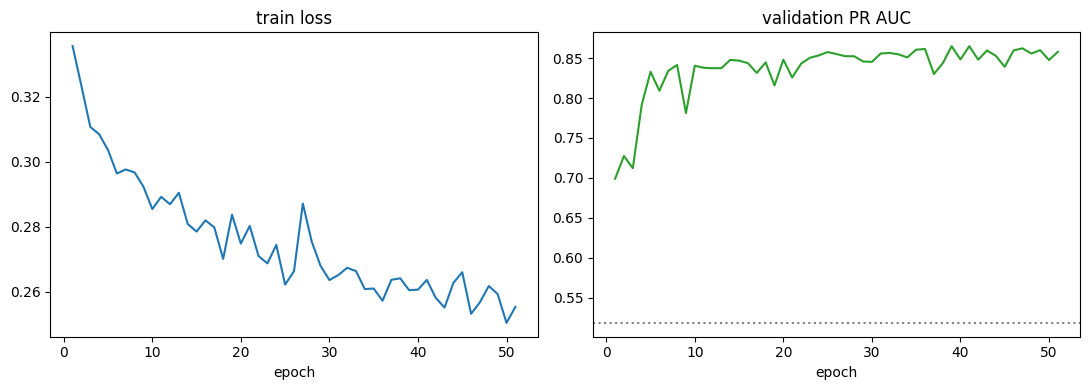

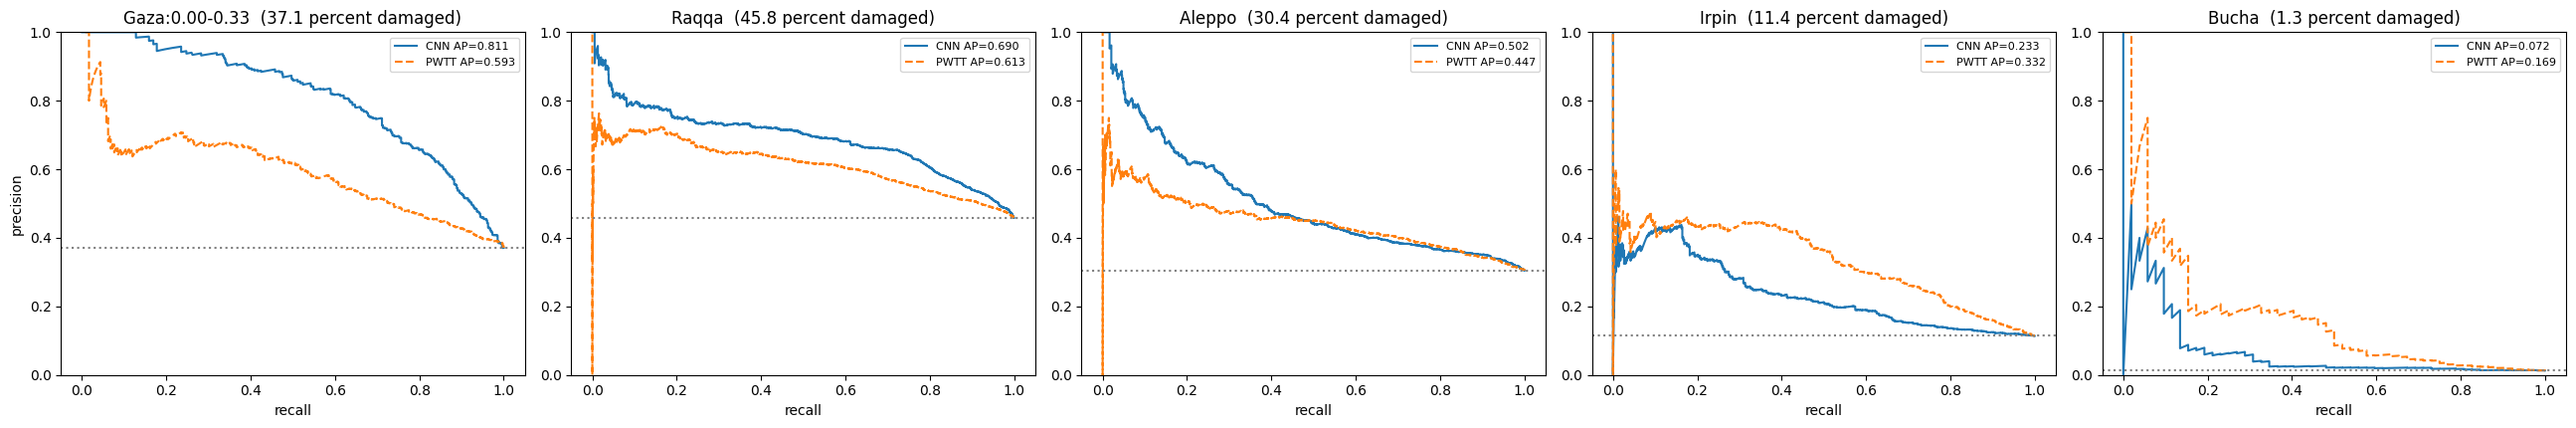

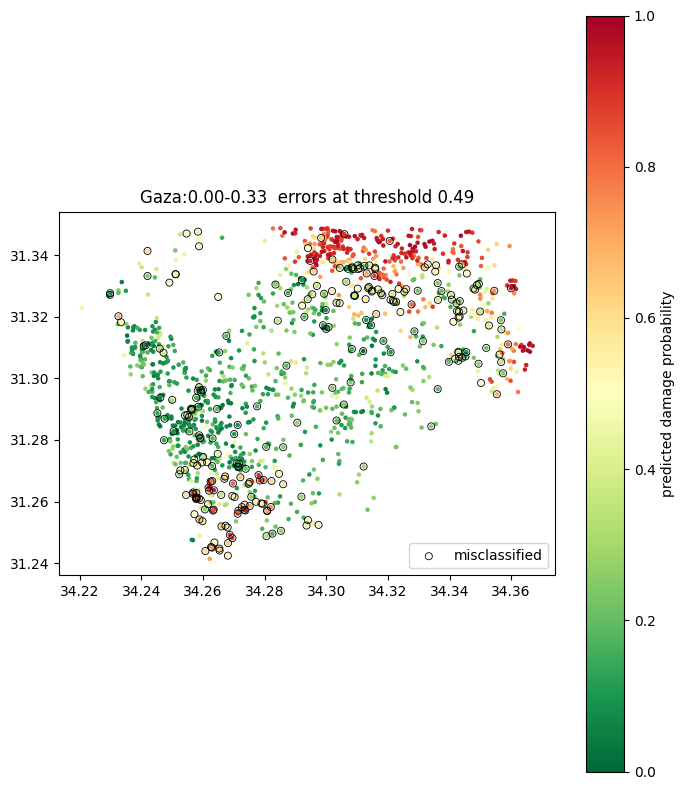

In [27]:
def plot_training(history, path):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(history[:, 0], history[:, 1])
    ax[0].set_xlabel("epoch")
    ax[0].set_title("train loss")
    ax[1].plot(history[:, 0], history[:, 2], color="C2")
    ax[1].axhline(y_va.mean(), color="gray", ls=":")
    ax[1].set_xlabel("epoch")
    ax[1].set_title("validation PR AUC")
    plt.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()


def plot_pr_curves(parts, path):
    n = len(parts)
    fig, axes = plt.subplots(1, n, figsize=(5.2 * n, 4.4))
    axes = np.atleast_1d(axes)
    for ax, p in zip(axes, parts):
        pr, rc, _ = precision_recall_curve(p["y"], p["probs"])
        ax.plot(rc, pr, label=f"CNN AP={average_precision_score(p['y'], p['probs']):.3f}")
        mc = p["gdf"]["max_change"].values
        pr2, rc2, _ = precision_recall_curve(p["y"], mc)
        ax.plot(rc2, pr2, "--", label=f"PWTT AP={average_precision_score(p['y'], mc):.3f}")
        ax.axhline(p["y"].mean(), color="gray", ls=":")
        ax.set_ylim(0, 1)
        ax.set_title(f"{p['name']}  ({p['y'].mean() * 100:.1f} percent damaged)")
        ax.set_xlabel("recall")
        ax.legend(fontsize=8)
    axes[0].set_ylabel("precision")
    plt.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()


def plot_error_map(part, threshold, path):
    gdf = part["gdf"]
    probs = part["probs"]
    pred = (probs >= threshold).astype(int)
    xs = gdf["centroid"].apply(lambda p: p.x)
    ys = gdf["centroid"].apply(lambda p: p.y)
    fig, ax = plt.subplots(figsize=(7, 8))
    sc = ax.scatter(xs, ys, c=probs, s=5, cmap="RdYlGn_r", vmin=0, vmax=1)
    wrong = pred != part["y"]
    ax.scatter(xs[wrong], ys[wrong], facecolors="none", edgecolors="black",
               s=26, linewidths=0.6, label="misclassified")
    plt.colorbar(sc, ax=ax, label="predicted damage probability")
    ax.set_title(f"{part['name']}  errors at threshold {threshold:.2f}")
    ax.set_aspect("equal")
    ax.legend(loc="lower right")
    plt.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()


plot_training(run["history"], os.path.join(OUT["figures"], "training.png"))
plot_pr_curves(test_parts, os.path.join(OUT["figures"], "pr_curves.png"))
plot_error_map(test_parts[0], run["val_threshold"],
               os.path.join(OUT["figures"], "error_map.png"))

<h2>11. Inference</h2>

Applies a trained checkpoint to any registered city and writes a GeoJSON of footprints
with probabilities, ready for GIS tools or the interactive map. Spatial smoothing from
Section 6 is applied here when enabled, neighbour consensus at prediction time is the
cheap version of spatial context modelling. A learned spatial context model, for
example a graph network over building adjacency, would slot in at this same point.

In [28]:
def predict_city(city, model=model, cfg=CONFIG, date=None):
    """Score every extracted building of one city and return its GeoDataFrame."""
    d = get_city(city, date, cfg)
    Xn = (select_channels(d, cfg) - mu) / sd
    tn = (d["tab"] - tab_mu) / tab_sd
    probs = predict_probs(model, Xn, tn)

    smooth_cfg = cfg["augmentation"]["spatial_smoothing"]
    if smooth_cfg["enabled"]:
        probs = spatial_smooth_scores(d["gdf"], probs,
                                      k=smooth_cfg["k"], weight=smooth_cfg["weight"])

    out = d["gdf"][["geometry", "class", "max_change"]].copy()
    out["prob"] = probs
    out["pred"] = (probs >= run["val_threshold"]).astype(int)
    path = os.path.join(OUT["predictions"], f"{city}_{d['date']}.geojson")
    out.drop(columns=[c for c in ["centroid"] if c in out]).to_file(path, driver="GeoJSON")
    print(f"wrote {path}")
    return out


gaza_pred = predict_city("Gaza")
gaza_pred.head(3)

wrote experiments/exp001_small_cnn_sar/predictions/Gaza_20240503.geojson


,geometry,class,max_change,prob,pred
84828,"POLYGON ((34.27226 31.27105, 34.27232 31.27096...",0,2.131464,0.102691,0
85309,"POLYGON ((34.29195 31.29619, 34.29197 31.29618...",0,2.096974,0.129480,0
38485,"POLYGON ((34.44391 31.5314, 34.44403 31.53135,...",1,2.996506,0.737621,1


<h2>12. Explainable AI</h2>

Three complementary views of what the model uses.

<b>Grad-CAM</b> shows which pixels of a patch drove one prediction, useful for checking
that the model looks at the building and not at an artifact.
<b>Modality ablation</b> zeroes one channel group at a time and measures the PR AUC
drop, the honest answer to which sensor matters.
<b>Permutation importance</b> shuffles one tabular feature at a time, only meaningful
when pwtt_tabular is enabled. SHAP would give per building attributions for the tabular
branch and is left as a marked extension point.

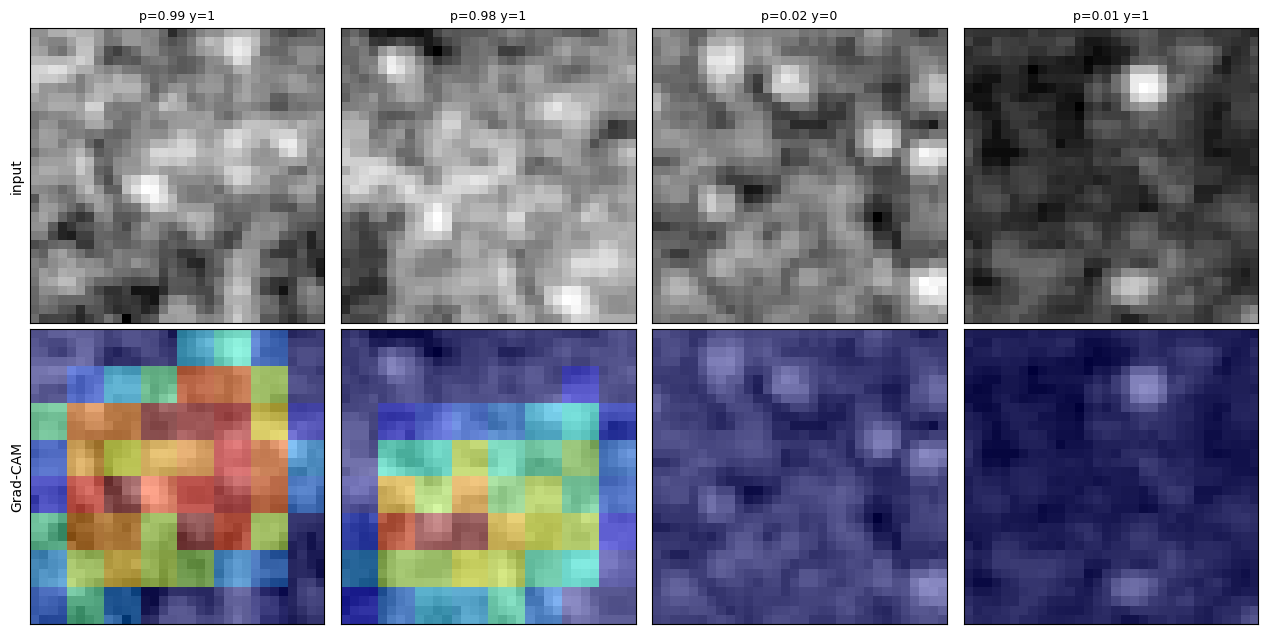

full input         0.8107
without s1 pre     0.5683
without s1 post    0.3603
Name: PR_AUC, dtype: float64
pwtt_tabular is disabled in this run, nothing to permute


In [29]:
def grad_cam(model, x, tab):
    """Gradient weighted class activation map from the last conv layer."""
    convs = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    target = convs[-1]
    acts, grads = {}, {}

    def fwd_hook(module, inp, out):
        acts["v"] = out.detach()

    def bwd_hook(module, gin, gout):
        grads["v"] = gout[0].detach()

    h1 = target.register_forward_hook(fwd_hook)
    h2 = target.register_full_backward_hook(bwd_hook)
    model.eval()
    xb = torch.from_numpy(x[None]).to(device).requires_grad_(True)
    tb = torch.from_numpy(tab[None]).to(device)
    logit = model(xb, tb)
    model.zero_grad()
    logit.backward()
    h1.remove()
    h2.remove()

    weight = grads["v"].mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weight * acts["v"]).sum(dim=1))[0].cpu().numpy()
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam, float(torch.sigmoid(logit).item())


def show_grad_cam_examples(part, n=4, path=None):
    """Grad-CAM for the highest scoring damaged and intact examples of a region."""
    Xn = (part["X"] - mu) / sd
    tn = (part["tab"] - tab_mu) / tab_sd
    order = np.argsort(-part["probs"])
    picks = list(order[:n // 2]) + list(order[-(n - n // 2):])
    fig, axes = plt.subplots(2, len(picks), figsize=(3.2 * len(picks), 6.4))
    for col, j in enumerate(picks):
        cam, prob = grad_cam(model, Xn[j], tn[j])
        cam_big = np.kron(cam, np.ones((Xn.shape[2] // cam.shape[0],
                                        Xn.shape[3] // cam.shape[1])))
        base = Xn[j, min(2, Xn.shape[0] - 1)]
        axes[0, col].imshow(base, cmap="gray")
        axes[0, col].set_title(f"p={prob:.2f} y={part['y'][j]}", fontsize=9)
        axes[1, col].imshow(base, cmap="gray")
        axes[1, col].imshow(cam_big, cmap="jet", alpha=0.45)
        for ax in (axes[0, col], axes[1, col]):
            ax.set_xticks([])
            ax.set_yticks([])
    axes[0, 0].set_ylabel("input")
    axes[1, 0].set_ylabel("Grad-CAM")
    plt.tight_layout()
    if path:
        fig.savefig(path, dpi=150)
    plt.show()


def modality_ablation(part):
    """PR AUC after zeroing each channel group, big drop means the group matters."""
    groups = {}
    for i, name in enumerate(CHANNEL_NAMES):
        key = name.split("_")[0] + " " + ("pre" if "_pre_" in name else "post")
        groups.setdefault(key, []).append(i)
    Xn = (part["X"] - mu) / sd
    tn = (part["tab"] - tab_mu) / tab_sd
    base = average_precision_score(part["y"], predict_probs(model, Xn, tn))
    rows = {"full input": base}
    for key, idx in groups.items():
        Xz = Xn.copy()
        Xz[:, idx] = 0.0
        rows[f"without {key}"] = average_precision_score(
            part["y"], predict_probs(model, Xz, tn))
    return pd.Series(rows, name="PR_AUC")


def permutation_importance_tab(part, repeats=3):
    """Shuffle one tabular feature at a time, only meaningful with pwtt_tabular on."""
    if N_TAB == 0:
        print("pwtt_tabular is disabled in this run, nothing to permute")
        return None
    rng = np.random.default_rng(CONFIG["seed"])
    Xn = (part["X"] - mu) / sd
    tn = (part["tab"] - tab_mu) / tab_sd
    base = average_precision_score(part["y"], predict_probs(model, Xn, tn))
    rows = {}
    for j, name in enumerate(TAB_FEATURES):
        drops = []
        for _ in range(repeats):
            tp = tn.copy()
            rng.shuffle(tp[:, j])
            drops.append(base - average_precision_score(
                part["y"], predict_probs(model, Xn, tp)))
        rows[name] = float(np.mean(drops))
    return pd.Series(rows, name="PR_AUC drop").sort_values(ascending=False)

# SHAP extension point: shap.DeepExplainer on the tabular branch would give per
# building attributions, add it here once the fusion model is the main model.

show_grad_cam_examples(test_parts[0], n=4,
                       path=os.path.join(OUT["figures"], "grad_cam.png"))
abl = modality_ablation(test_parts[0])
print(abl.round(4))
perm = permutation_importance_tab(test_parts[0])
if perm is not None:
    print(perm.round(4))

<h2>13. Interactive comparison map</h2>

A folium map over RGB satellite imagery for visual quality control and for the long
term goal of a living damage map. Layers, each toggleable in the control:

<ul>
<li><b>Ground truth</b>, footprints coloured by the UNOSAT label</li>
<li><b>Prediction</b>, footprints coloured by model confidence</li>
<li><b>Disagreements</b>, false positives and false negatives outlined so they jump out</li>
</ul>

Tooltips show probability, label and the PWTT statistic per building. When a city has
several prediction files, one per assessment date, the date selector rebuilds the map.
This runs on plain folium tiles, no Earth Engine session needed.

In [30]:
import folium
import matplotlib


def prob_to_color(p):
    return matplotlib.colors.to_hex(matplotlib.colormaps["RdYlGn_r"](float(p)))


def build_comparison_map(pred_gdf, title="damage map", max_features=4000):
    """Folium map with ground truth, predictions and disagreement layers."""
    g = pred_gdf
    if len(g) > max_features:
        g = g.sample(max_features, random_state=0)
    g = g.copy()
    g["color_pred"] = [prob_to_color(p) for p in g["prob"]]
    g["color_true"] = np.where(g["class"] == 1, "#C0392B", "#4C72B0")
    g["agree"] = g["pred"] == g["class"]

    center = [g.geometry.centroid.y.mean(), g.geometry.centroid.x.mean()]
    m = folium.Map(location=center, zoom_start=14, tiles=None)
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/"
              "World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri World Imagery", name="RGB satellite").add_to(m)

    def add_layer(frame, color_col, name, show, weight=1, fill=0.7, outline=None):
        fields = ["prob", "class", "pred", "max_change"]
        gj = folium.GeoJson(
            frame[["geometry", "prob", "class", "pred", "max_change", color_col]].to_json(),
            name=name,
            show=show,
            style_function=lambda f, cc=color_col, w=weight, fo=fill, ol=outline: {
                "color": ol or f["properties"][cc],
                "fillColor": f["properties"][cc],
                "weight": w,
                "fillOpacity": fo,
            },
            tooltip=folium.GeoJsonTooltip(fields=fields,
                                          aliases=["confidence", "true label",
                                                   "predicted", "PWTT max_change"]))
        gj.add_to(m)

    add_layer(g, "color_true", "ground truth", show=False)
    add_layer(g, "color_pred", "prediction confidence", show=True)
    dis = g[~g["agree"]]
    if len(dis):
        add_layer(dis, "color_pred", "disagreements", show=True,
                  weight=3, fill=0.0, outline="#00FFFF")
    folium.LayerControl(collapsed=False).add_to(m)
    return m


def comparison_map_with_dates(city):
    """Wrap the map in a date dropdown when the city has several predictions."""
    files = sorted(f for f in os.listdir(OUT["predictions"])
                   if f.startswith(city) and f.endswith(".geojson"))
    if not files:
        raise FileNotFoundError(f"no prediction files for {city}, run Section 11 first")

    def load(fname):
        return gpd.read_file(os.path.join(OUT["predictions"], fname))

    if len(files) == 1:
        return build_comparison_map(load(files[0]), title=files[0])
    try:
        import ipywidgets as widgets
        from IPython.display import display, clear_output
        dropdown = widgets.Dropdown(options=files, description="date")
        out = widgets.Output()

        def on_change(change):
            if change["name"] == "value":
                with out:
                    clear_output()
                    display(build_comparison_map(load(change["new"])))
        dropdown.observe(on_change, names="value")
        with out:
            display(build_comparison_map(load(files[0])))
        display(dropdown, out)
    except ImportError:
        print("ipywidgets missing, showing the newest date only")
        return build_comparison_map(load(files[-1]))


comparison_map_with_dates("Gaza")

/tmp/ipykernel_1262/3711485480.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = [g.geometry.centroid.y.mean(), g.geometry.centroid.x.mean()]
/usr/local/lib/python3.12/dist-packages/folium/features.py:1204: UserWarning: GeoJsonTooltip is not configured to render for GeoJson GeometryCollection geometries. Please consider reworking these features: [{'prob': 0.79952598, 'class': 1, 'pred': 1, 'max_change': 4.630429629585487, 'color_true': '#C0392B'}] to MultiPolygon for full functionality.
https://tools.ietf.org/html/rfc7946#page-9
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/folium/features.py:1204: UserWarning: GeoJsonTooltip is not configured to render for GeoJson GeometryCollection geometries. Please consider reworking these features: [{'prob': 0.79952598, 'class': 1, 'pred': 1, 'max_change': 4.630429629585487, 'color_pred

<h2>14. Extending the pipeline</h2>

Cheat sheet for the group.

<ul>
<li><b>New city or date</b>: export its rasters with the prototype GEE cells, then one
<code>add_city</code> call or registry entry. Nothing else changes.</li>
<li><b>New data source</b>: append channel names to <code>FULL_CHANNELS</code>, teach
<code>extract_city</code> to read the raster, add a switch in CONFIG features and a rule
in <code>active_channel_indices</code>.</li>
<li><b>New model</b>: a class with <code>forward(x, tab)</code> plus
<code>@register_model("name")</code>, then set CONFIG model to that name.</li>
<li><b>Pretrained backbone</b> (required by the project brief): register a model that
wraps torchvision ResNet18, average the RGB stem weights into our channel count, and
compare against small_cnn under this identical protocol.</li>
<li><b>Segmentation</b>: rasterize UNOSAT polygons into masks, add a
SegmentationDataset, remove the guard in Section 8, unet is ready.</li>
<li><b>Temporal smoothing</b>: add a second assessment date to a city registry entry
and feed both frames through <code>expand_labels_over_time</code>.</li>
<li><b>Experiment comparison</b>: every run writes config, metrics, figures and
predictions under <code>experiments/{name}</code>, diff two runs by diffing folders.</li>
</ul>